Word Embeddings

In [13]:
!pip install gensim
import gensim
import nltk
from nltk.tokenize import word_tokenize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Download NLTK data required for tokenization
nltk.download('punkt')
nltk.download('punkt_tab')

print("Libraries imported and NLTK data downloaded.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...


Libraries imported and NLTK data downloaded.


[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [19]:
corpus = [
    "Human machine interface for lab experiment",
    "A survey of user opinion of computer system response time",
    "The EPS user interface management system",
    "System and human system engineering testing of EPS",
    "Relation of user perceived response time to error measurement",
    "The generation of random binary unordered trees",
    "The intersection of graph theory and trees",
    "Graph minors IV Widths of trees and well quasi ordering",
    "Graph minors A survey",
    "AI and machine learning are revolutionizing industries",
    "Artificial intelligence is changing the world",
    "Machine learning algorithms are at the core of AI",
    "Data science and AI are closely related"
]

# Tokenize and lowercase the words
tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]

print("Original corpus:")
for sentence in corpus:
    print(f"- {sentence}")

print("\nTokenized corpus (first 2 sentences):")
for tokens in tokenized_corpus[:2]:
    print(f"- {tokens}")

Original corpus:
- Human machine interface for lab experiment
- A survey of user opinion of computer system response time
- The EPS user interface management system
- System and human system engineering testing of EPS
- Relation of user perceived response time to error measurement
- The generation of random binary unordered trees
- The intersection of graph theory and trees
- Graph minors IV Widths of trees and well quasi ordering
- Graph minors A survey
- AI and machine learning are revolutionizing industries
- Artificial intelligence is changing the world
- Machine learning algorithms are at the core of AI
- Data science and AI are closely related

Tokenized corpus (first 2 sentences):
- ['human', 'machine', 'interface', 'for', 'lab', 'experiment']
- ['a', 'survey', 'of', 'user', 'opinion', 'of', 'computer', 'system', 'response', 'time']


## Training a Word2Vec Model


In [15]:
from gensim.models import Word2Vec

# Train the Word2Vec model
model = Word2Vec(
    sentences=tokenized_corpus,
    vector_size=100,  # Embedding size
    window=5,         # Context window size
    min_count=1,      # Ignore words with frequency less than 1
    sg=1,             # Use Skip-gram
    epochs=100        # Number of training iterations
)

print("Word2Vec model trained successfully.")
print(f"Vocabulary size: {len(model.wv.index_to_key)}")

Word2Vec model trained successfully.
Vocabulary size: 57


## Exploring Word Similarities



In [16]:
def find_similar_words(word, topn=5):
    if word in model.wv:
        print(f"Words similar to '{word}':")
        for similar_word, similarity in model.wv.most_similar(word, topn=topn):
            print(f"- {similar_word} (similarity: {similarity:.4f})")
    else:
        print(f"'{word}' not in vocabulary.")

find_similar_words('ai')
find_similar_words('machine')
find_similar_words('system')
find_similar_words('trees')
find_similar_words('computer')

Words similar to 'ai':
- the (similarity: 0.5232)
- are (similarity: 0.5002)
- artificial (similarity: 0.4929)
- and (similarity: 0.4823)
- of (similarity: 0.4767)
Words similar to 'machine':
- of (similarity: 0.6804)
- the (similarity: 0.5665)
- user (similarity: 0.5114)
- is (similarity: 0.5087)
- opinion (similarity: 0.5046)
Words similar to 'system':
- and (similarity: 0.4572)
- response (similarity: 0.4562)
- the (similarity: 0.4367)
- error (similarity: 0.4320)
- user (similarity: 0.4312)
Words similar to 'trees':
- of (similarity: 0.6648)
- the (similarity: 0.6197)
- iv (similarity: 0.6103)
- related (similarity: 0.5845)
- and (similarity: 0.5289)
Words similar to 'computer':
- the (similarity: 0.5946)
- user (similarity: 0.5840)
- of (similarity: 0.5723)
- is (similarity: 0.5014)
- perceived (similarity: 0.4970)


## Visualizing Word Embeddings

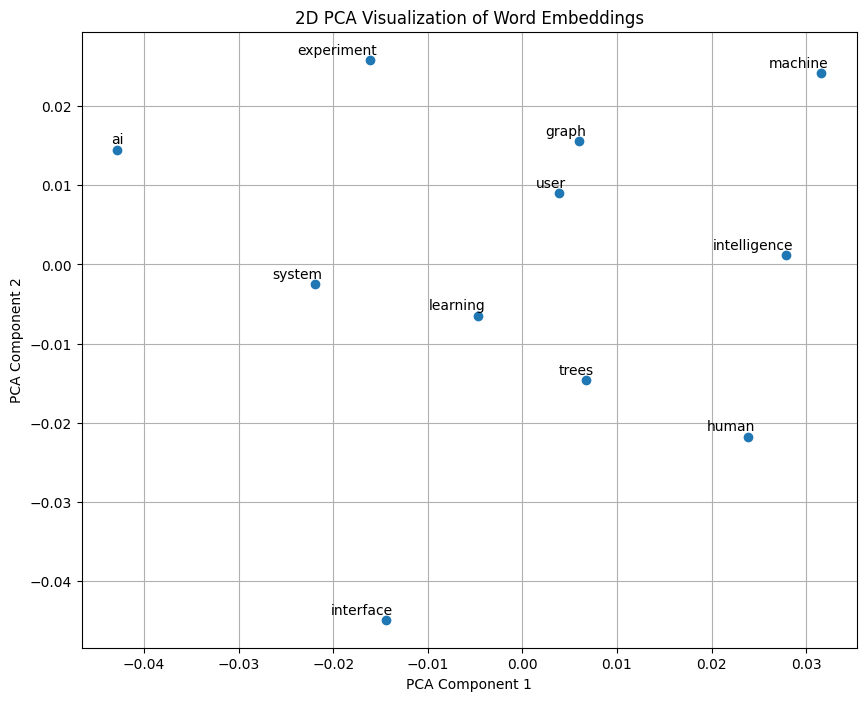

In [20]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select a subset of words to visualize
words_to_visualize = [
    'ai', 'machine', 'learning', 'intelligence', 'system', 'user',
    'interface', 'human', 'graph', 'trees', 'experiment'
]

# Filter words that are in our model's vocabulary
filtered_words = [word for word in words_to_visualize if word in model.wv]

if not filtered_words:
    print("None of the selected words are in the model's vocabulary. Please check your word list or corpus.")
else:
    # Get the vectors for the filtered words
    X = model.wv[filtered_words]

    # Apply PCA to reduce to 2 dimensions
    pca = PCA(n_components=2)
    result = pca.fit_transform(X)

    # Create a scatter plot
    plt.figure(figsize=(10, 8))
    plt.scatter(result[:, 0], result[:, 1])

    for i, word in enumerate(filtered_words):
        plt.annotate(word, xy=(result[i, 0], result[i, 1]), xytext=(5, 2),
                     textcoords='offset points', ha='right', va='bottom')

    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title('2D PCA Visualization of Word Embeddings')
    plt.grid(True)
    plt.show()